# 1. Importações

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from time import time

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline  # Importação do Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

 
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# 2. Carregamento do Dataset

In [ ]:
df = pd.read_csv("sudeste.csv") 

print("Linhas:", len(df))
print(df.info())
print(df.head())

Linhas: 1348416
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1348416 entries, 0 to 1348415
Data columns (total 19 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   ano             1348416 non-null  int64  
 1   sexo            1348416 non-null  object 
 2   exposicao1      1348416 non-null  float64
 3   premio1         1348416 non-null  float64
 4   is_media        1348416 non-null  float64
 5   freq_sin1       1348416 non-null  int64  
 6   indeniz1        1348416 non-null  int64  
 7   freq_sin2       1348416 non-null  int64  
 8   indeniz2        1348416 non-null  int64  
 9   freq_sin3       1348416 non-null  int64  
 10  indeniz3        1348416 non-null  int64  
 11  freq_sin4       1348416 non-null  int64  
 12  indeniz4        1348416 non-null  int64  
 13  freq_sin9       1348416 non-null  int64  
 14  indeniz9        1348416 non-null  int64  
 15  categoria_desc  1348416 non-null  object 
 16  faixa_desc      1348

# 3. Tratamento da Base

## 3.1 - Remoção de Coluna Com Alta Probabilidade de Vazamento de Dados

In [47]:
# Remover uma única coluna
df = df.drop(columns=['exposicao1'])

## 3.2 - Descrição da Base

In [48]:
print(df.info())
df.describe().T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1348416 entries, 0 to 1348415
Data columns (total 18 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   ano             1348416 non-null  int64  
 1   sexo            1348416 non-null  object 
 2   premio1         1348416 non-null  float64
 3   is_media        1348416 non-null  float64
 4   freq_sin1       1348416 non-null  int64  
 5   indeniz1        1348416 non-null  int64  
 6   freq_sin2       1348416 non-null  int64  
 7   indeniz2        1348416 non-null  int64  
 8   freq_sin3       1348416 non-null  int64  
 9   indeniz3        1348416 non-null  int64  
 10  freq_sin4       1348416 non-null  int64  
 11  indeniz4        1348416 non-null  int64  
 12  freq_sin9       1348416 non-null  int64  
 13  indeniz9        1348416 non-null  int64  
 14  categoria_desc  1348416 non-null  object 
 15  faixa_desc      1348416 non-null  object 
 16  estado          1348416 non-null  ob

,count,mean,std,min,25%,50%,75%,max
ano,1348416.0,2012.538338,4.811972,1.999000e+03,2010.000000,2013.000000,2016.000000,2.021000e+03
premio1,1348416.0,6156.248651,19833.866304,8.526513e-14,567.431339,1432.842709,4352.617870,1.414842e+06
is_media,1348416.0,42064.938643,42807.729503,0.000000e+00,21380.246343,33433.089787,50474.321526,3.929298e+06
freq_sin1,1348416.0,0.040436,0.313950,0.000000e+00,0.000000,0.000000,0.000000,4.300000e+01
indeniz1,1348416.0,1126.424933,8753.207720,0.000000e+00,0.000000,0.000000,0.000000,6.143660e+05
freq_sin2,1348416.0,0.241936,1.027437,0.000000e+00,0.000000,0.000000,0.000000,5.400000e+01
indeniz2,1348416.0,1251.436008,5994.980284,0.000000e+00,0.000000,0.000000,0.000000,4.148870e+05
freq_sin3,1348416.0,0.030764,0.196710,0.000000e+00,0.000000,0.000000,0.000000,1.300000e+01
indeniz3,1348416.0,1014.250311,7649.709945,0.000000e+00,0.000000,0.000000,0.000000,1.198502e+06
freq_sin4,1348416.0,0.001090,0.034601,0.000000e+00,0.000000,0.000000,0.000000,3.000000e+00


## 3.3 - Verificação de Valores Nulos

In [49]:
df.isnull().sum()


ano               0
sexo              0
premio1           0
is_media          0
freq_sin1         0
indeniz1          0
freq_sin2         0
indeniz2          0
freq_sin3         0
indeniz3          0
freq_sin4         0
indeniz4          0
freq_sin9         0
indeniz9          0
categoria_desc    0
faixa_desc        0
estado            0
idade_veiculo     0
dtype: int64

# 4. Plot de Matriz de Correlação com Variáveis Numéricas

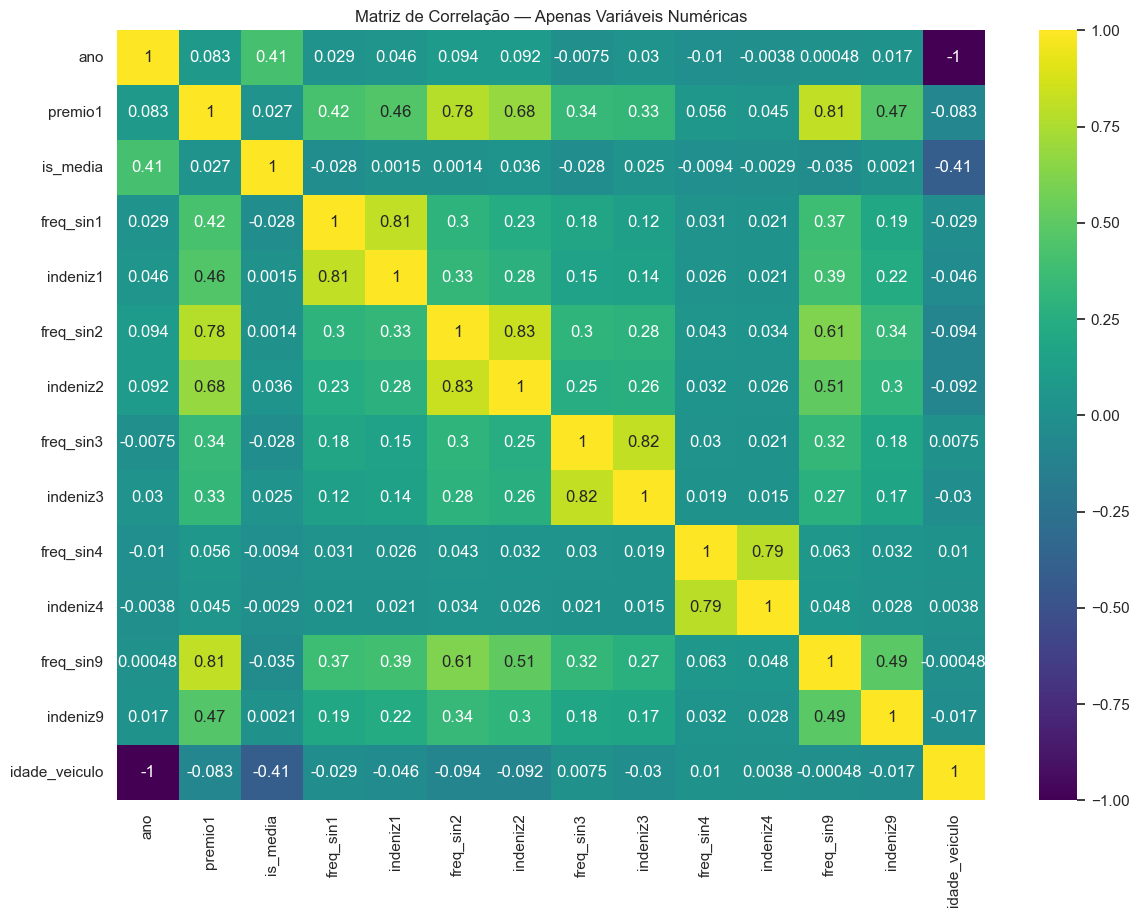

In [50]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.select_dtypes(include=['number']).corr(),
            annot=True, cmap="viridis")
plt.title("Matriz de Correlação — Apenas Variáveis Numéricas")
plt.show()


# 5. Transformação das Variáveis Categóricas em Numéricas (OneHotEncoder)

In [51]:
categoricas = ['sexo', 'categoria_desc', 'faixa_desc', 'estado']

df_encoded = pd.get_dummies(df, columns=categoricas, drop_first=True)

df_encoded.head()


,ano,premio1,is_media,freq_sin1,indeniz1,freq_sin2,indeniz2,freq_sin3,indeniz3,freq_sin4,...,sexo_Masculino,categoria_desc_Carro_nacional,categoria_desc_Motocicleta,faixa_desc_Entre 26 e 35 anos,faixa_desc_Entre 36 e 45 anos,faixa_desc_Entre 46 e 55 anos,faixa_desc_Maior que 55 anos,estado_MG,estado_RJ,estado_SP
0,2015,1170.021732,55210.946951,0,0,0,0,0,0,0,...,True,True,False,False,True,False,False,False,False,True
1,2013,9195.987169,30880.876814,0,0,0,0,0,0,0,...,True,True,False,True,False,False,False,False,False,True
2,2005,457.707687,12195.242935,0,0,1,3419,0,0,0,...,False,True,False,True,False,False,False,False,False,True
3,2017,4566.403672,10084.018876,0,0,0,0,0,0,0,...,True,False,True,True,False,False,False,False,True,False
4,2007,1132.788696,55572.216230,0,0,0,0,0,0,0,...,True,False,True,False,False,False,True,False,False,True


# 6. Definição da Variável Target

In [52]:
target = "premio1"   # ajuste se necessário

X = df_encoded.drop(columns=[target])
y = df_encoded[target]

X.shape, y.shape


((1348416, 23), (1348416,))

# 7. Split de Treino / Teste

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 8. Regressão Linear com Scaler

In [54]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])


# 9. Ajuste dos Hiperparâmetros com GridSearch

In [55]:
# Definir os hiperparâmetros para o GridSearch
param_grid = {
    'model__fit_intercept': [True, False],
}

# Criar o GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Ajustar o GridSearchCV com os dados de treino
try:
    grid_search.fit(X_train, y_train)
    print("Ajuste do GridSearch concluído.")
    print(f"Número de combinações testadas: {len(grid_search.cv_results_['params'])}")
    print(f"Melhor score: {grid_search.best_score_}")
    print("Melhores hiperparâmetros:", grid_search.best_params_)
except Exception as e:
    print(f"Ocorreu um erro durante o ajuste: {e}")


Ajuste do GridSearch concluído.
Número de combinações testadas: 2
Melhor score: -76902004.66318288
Melhores hiperparâmetros: {'model__fit_intercept': True}


# 10. Cross-Validation (K-fold) na Regressão Linear

In [56]:
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

cv_r2 = cross_val_score(pipeline, X, y, cv=kf, scoring='r2')
cv_rmse = np.sqrt(-cross_val_score(pipeline, X, y, cv=kf, scoring='neg_mean_squared_error'))
cv_mae = -cross_val_score(pipeline, X, y, cv=kf, scoring='neg_mean_absolute_error')

print("===== RESULTADOS K-FOLD =====")
print("R² médio:", cv_r2.mean())
print("RMSE médio:", cv_rmse.mean())
print("MAE médio:", cv_mae.mean())


===== RESULTADOS K-FOLD =====
R² médio: 0.8070245631840078
RMSE médio: 8708.611461790675
MAE médio: 3593.422203478121


# 11. Validação Hold-Out 

In [57]:
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("\n===== RESULTADOS HOLD-OUT =====")
print("R² :", r2)
print("RMSE:", rmse)
print("MAE :", mae)



===== RESULTADOS HOLD-OUT =====
R² : 0.8154534549067175
RMSE: 8480.767424391264
MAE : 3579.197051241733


# 12. Plotagem dos Valores Reais vs Preditos

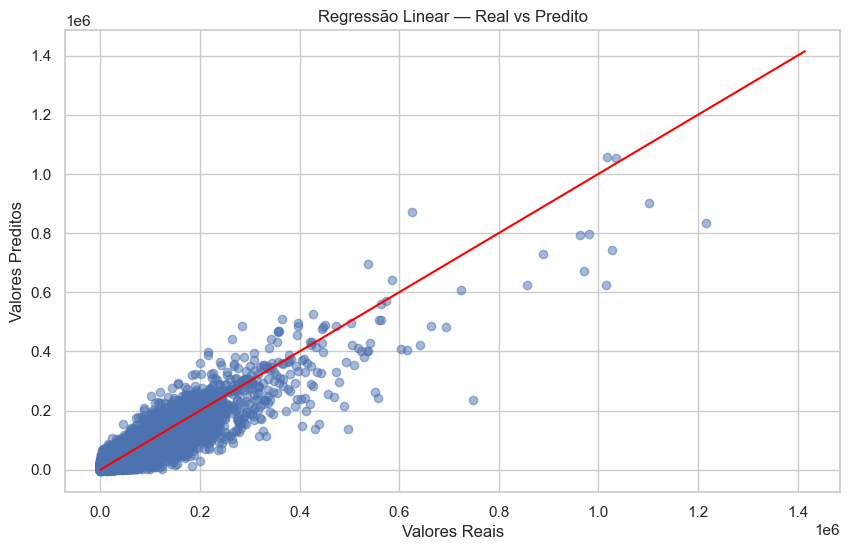

In [ ]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Valores Reais")
plt.ylabel("Valores Preditos")
plt.title("Regressão Linear — Real vs Predito")
plt.plot([y.min(), y.max()], [y.min(), y.max()], color="red")
plt.show()

# 13. Importação do Modelo de Regressão em joblib

In [59]:
import joblib

joblib.dump(pipeline, "modelo_regressao_linear_kfold.pkl")
print("Modelo salvo como modelo_regressao_linear_kfold.pkl")


Modelo salvo como modelo_regressao_linear_kfold.pkl


# 14. GradientBoosting Regressor

## 14.1 Carregamento e Visualização dos Dados

In [71]:
DATA_PATH = ("sudeste.csv") 

In [ ]:

try:
    df = pd.read_csv(DATA_PATH)
except FileNotFoundError:
    raise FileNotFoundError(f"Arquivo não encontrado em {DATA_PATH}. Verifique o caminho ou converta o notebook {UPLOADED_FILE_PATH} para um CSV e atualize DATA_PATH.")

print("Shape:", df.shape)
display(df.head())

Shape: (1348416, 19)


,ano,sexo,exposicao1,premio1,is_media,freq_sin1,indeniz1,freq_sin2,indeniz2,freq_sin3,indeniz3,freq_sin4,indeniz4,freq_sin9,indeniz9,categoria_desc,faixa_desc,estado,idade_veiculo
0,2015,Masculino,1.054794,1170.021732,55210.946951,0,0,0,0,0,0,0,0,0,0,Carro_nacional,Entre 36 e 45 anos,SP,5
1,2013,Masculino,6.315068,9195.987169,30880.876814,0,0,0,0,0,0,0,0,2,246,Carro_nacional,Entre 26 e 35 anos,SP,7
2,2005,Feminino,0.608219,457.707687,12195.242935,0,0,1,3419,0,0,0,0,1,329,Carro_nacional,Entre 26 e 35 anos,SP,15
3,2017,Masculino,8.547945,4566.403672,10084.018876,0,0,0,0,0,0,0,0,0,0,Motocicleta,Entre 26 e 35 anos,RJ,3
4,2007,Masculino,0.506849,1132.788696,55572.216230,0,0,0,0,0,0,0,0,0,0,Motocicleta,Maior que 55 anos,SP,13


## 14.2 Remoção de Coluna Com Alta Probabilidade de Vazamento de Dados

In [ ]:

df = df.drop(columns=['exposicao1'])

## 14.3 Categorização e Definição de Variável Target

In [ ]:

categorical_cols = ['sexo', 'categoria_desc', 'faixa_desc', 'estado']
target = 'premio1'   # ajuste caso a variável alvo seja diferente

## 14.4 Verificação de Nulos

In [ ]:

print("Nulos por coluna:\n", df.isnull().sum())


Nulos por coluna:
 ano               0
sexo              0
premio1           0
is_media          0
freq_sin1         0
indeniz1          0
freq_sin2         0
indeniz2          0
freq_sin3         0
indeniz3          0
freq_sin4         0
indeniz4          0
freq_sin9         0
indeniz9          0
categoria_desc    0
faixa_desc        0
estado            0
idade_veiculo     0
dtype: int64


## 14.5 Split de Treino / Teste

In [ ]:

X = df.drop(columns=[target])
y = df[target].copy()


## 14.6 Pré-processamento

In [ ]:
ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)


preprocessor = ColumnTransformer(
    transformers=[
        ('ohe', ohe, categorical_cols)
    ],
    remainder='passthrough'  # mantém as demais colunas numéricas como estão
)

# Aplicar pré-processamento (apenas para verificar dimensões; para treino usaremos pipeline implícito)
X_pre = preprocessor.fit_transform(X)
print("After encoding shape:", X_pre.shape)

After encoding shape: (1348416, 23)


## 14.7 - Ajuste do Pré-processamento

In [ ]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

# Ajustar préprocessor em X_train e transformar ambos
preprocessor = ColumnTransformer(
    transformers=[
        ('ohe', ohe, categorical_cols)
    ],
    remainder='passthrough'
)
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

## 14.8 - Modelagem com GridSearchCV

In [ ]:

param_grid = {
    'max_iter': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [6, 8, 10]
}

grid_search = GridSearchCV(
    HistGradientBoostingRegressor(early_stopping=True, validation_fraction=0.1, random_state=42, verbose=0),
    param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1
)

t0 = time()
grid_search.fit(X_train, y_train)
t1 = time()
print(f"Treinamento finalizado em {t1-t0:.1f} s")

# Melhor modelo encontrado
best_model = grid_search.best_estimator_
print("Melhores hiperparâmetros:", grid_search.best_params_)

Treinamento finalizado em 1258.3 s
Melhores hiperparâmetros: {'learning_rate': 0.1, 'max_depth': 10, 'max_iter': 300}


## 14.9 Validação Hold-Out


===== RESULTADOS HOLD-OUT (Gradient Boosting) =====
R²  : 0.860081
RMSE: 7384.4815
MAE : 3185.9839


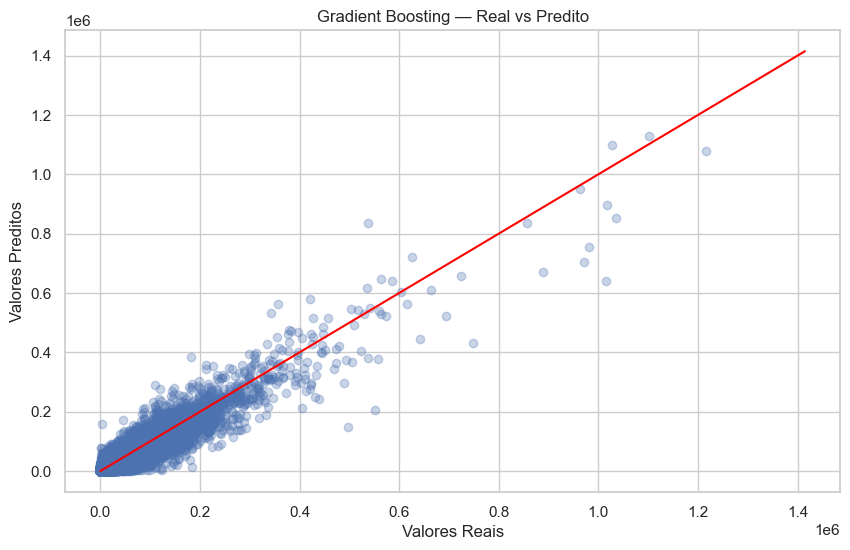

O modelo não possui o atributo 'feature_importances_'


In [ ]:

y_pred = best_model.predict(X_test)

# Calcular as métricas de avaliação
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

# Exibir os resultados
print("\n===== RESULTADOS HOLD-OUT (Gradient Boosting) =====")
print(f"R²  : {r2:.6f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")

# Gráfico real x predito
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red')
plt.xlabel("Valores Reais")
plt.ylabel("Valores Preditos")
plt.title("Gradient Boosting — Real vs Predito")
plt.show()


# Verifique se o modelo foi ajustado
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feature_names = preprocessor.get_feature_names_out()
    indices = np.argsort(importances)[::-1]

    # Plotar as 10 características mais importantes
    plt.figure(figsize=(10, 6))
    plt.title("Importância das Características")
    plt.bar(range(10), importances[indices][:10], align="center")
    plt.xticks(range(10), feature_names[indices][:10], rotation=90)
    plt.xlim([-1, 10])
    plt.show()
else:
    print("O modelo não possui o atributo 'feature_importances_'")



## 14.10 Cross-Validation (K-fold)

In [ ]:
sample_frac = 1.0   
if sample_frac < 1.0:
    X_cv = X.sample(frac=sample_frac, random_state=42)
    y_cv = y.loc[X_cv.index]
else:
    X_cv = X
    y_cv = y

X_cv_trans = preprocessor.transform(X_cv)

k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

cv_r2 = cross_val_score(best_model, X_cv_trans, y_cv, cv=kf, scoring='r2', n_jobs=-1)
cv_rmse = np.sqrt(-cross_val_score(best_model, X_cv_trans, y_cv, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1))
cv_mae = -cross_val_score(best_model, X_cv_trans, y_cv, cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)

print("\n===== RESULTADOS K-FOLD (Gradient Boosting) =====")
print(f"R² médio : {cv_r2.mean():.6f}  (std: {cv_r2.std():.6f})")
print(f"RMSE médio: {cv_rmse.mean():.4f} (std: {cv_rmse.std():.4f})")
print(f"MAE médio : {cv_mae.mean():.4f} (std: {cv_mae.std():.4f})")


===== RESULTADOS K-FOLD (Gradient Boosting) =====
R² médio : 0.857231  (std: 0.002049)
RMSE médio: 7491.6784 (std: 136.5450)
MAE médio : 3203.3587 (std: 8.1891)


## 14.11 Salvamento do Preprocessor e Modelo

In [ ]:
joblib.dump({'preprocessor': preprocessor, 'model': best_model}, 'gb_model_pipeline.joblib')
print("Pipeline salvo em gb_model_pipeline.joblib")

Pipeline salvo em gb_model_pipeline.joblib


# 15 Verificação de Vazamento de Dados


===== Correlação das variáveis com o alvo =====
premio1          1.000000
freq_sin9        0.805865
freq_sin2        0.780832
indeniz2         0.680587
indeniz9         0.467193
indeniz1         0.460933
freq_sin1        0.415772
freq_sin3        0.340429
indeniz3         0.326000
ano              0.082786
freq_sin4        0.056451
indeniz4         0.045060
is_media         0.026574
idade_veiculo   -0.082786
Name: premio1, dtype: float64


C:\Users\PR837UK\AppData\Local\Temp\ipykernel_19500\4176882463.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corrs.values, y=top_corrs.index, palette="viridis")


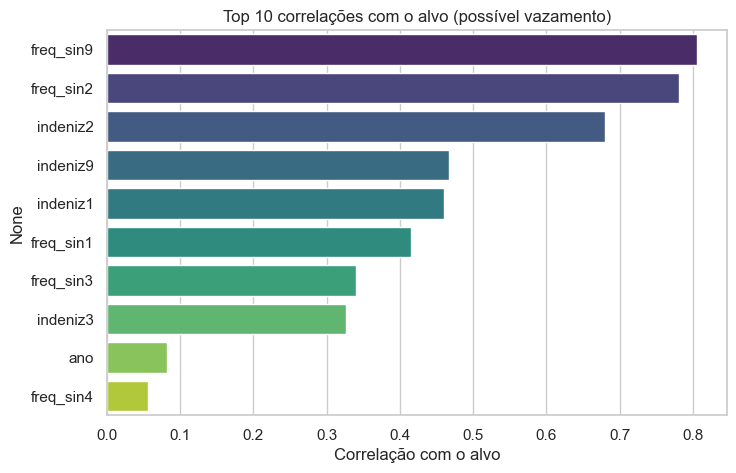

In [85]:
# Verificação de vazamento de dados

corrs = df.corr(numeric_only=True)[target].sort_values(ascending=False)
print("\n===== Correlação das variáveis com o alvo =====")
print(corrs)

# Plotar correlação das top 10 variáveis numéricas com o target
top_corrs = corrs.drop(target).head(10)
plt.figure(figsize=(8,5))
sns.barplot(x=top_corrs.values, y=top_corrs.index, palette="viridis")
plt.title("Top 10 correlações com o alvo (possível vazamento)")
plt.xlabel("Correlação com o alvo")
plt.show()


# 16. Teste de Underfitting / Overfitting

In [86]:
# Underfitting / Overfitting

y_train_pred = best_model.predict(X_train)

r2_train = r2_score(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

print("\n===== COMPARAÇÃO TREINO vs TESTE =====")
print(f"R² Treino : {r2_train:.6f}")
print(f"R² Teste  : {r2:.6f}")
print(f"RMSE Treino: {rmse_train:.4f}")
print(f"RMSE Teste : {rmse:.4f}")

# Diferença grande entre treino e teste sugere overfitting
# Ambos baixos sugerem underfitting


===== COMPARAÇÃO TREINO vs TESTE =====
R² Treino : 0.883790
R² Teste  : 0.815453
RMSE Treino: 6769.1065
RMSE Teste : 8480.7674
